# Notebook 3 Cocktail Forecast Engine — Executive Analysis

This notebook presents the commercial analysis generated from the forecasting engine.

The analysis demonstrates how menu strategy, seasonal demand drivers, and supplier product switches influence cocktail sales and profitability.

Key analyses include:

• Monthly gross profit trends  
• Menu initiative impact (Peach & Circumstance)  
• KI NO BI supplier usage tracking  
• Seasonal demand forecasting  
• Event-driven profit impact  

### 13) Portfolio Presentation Layer

#### Notebook 3 Setup

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

DB_PATH = Path("../db/cocktail_engine.db")
print("Using DB:", DB_PATH.resolve())

Using DB: /Users/carolineridgway/workbench/cocktail-engine/db/cocktail_engine.db


In [2]:
import sqlite3

with sqlite3.connect(DB_PATH) as con:
    cur = con.cursor()

    # -----------------------------
    # 1) Core exec source (qty + finance) — stable production layer
    # -----------------------------
    cur.execute("DROP VIEW IF EXISTS v_exec_source_core_13;")
    cur.execute("""
    CREATE VIEW v_exec_source_core_13 AS
    SELECT
        c.cocktail_id,
        c.cocktail_name,
        f.year,
        f.month,

        -- qty layer
        f.baseline_2026_qty,
        f.uplift,
        f.event_adjusted_2026_qty,
        f.reality_forecast_qty,

        -- finance layer (from the unified engine)
        fin.forecast_revenue,
        fin.forecast_cogs,
        fin.forecast_gross_profit
    FROM fact_reality_forecast_14f f
    JOIN dim_cocktail c
      ON c.cocktail_id = f.cocktail_id
    LEFT JOIN (
        SELECT
            cocktail_id,
            year,
            month,
            SUM(forecast_revenue)      AS forecast_revenue,
            SUM(forecast_cogs)         AS forecast_cogs,
            SUM(forecast_gross_profit) AS forecast_gross_profit
        FROM v_reality_financial_14g
        GROUP BY cocktail_id, year, month
    ) fin
      ON fin.cocktail_id = f.cocktail_id
     AND fin.year = f.year
     AND fin.month = f.month;
    """)

    # -----------------------------
    # 2) Manual add-on view (if you still use manual tables)
    #    - Keeps your existing manual table name if present
    # -----------------------------
    cur.execute("DROP VIEW IF EXISTS v_exec_source_plus_manual_13;")
    cur.execute("""
    CREATE VIEW v_exec_source_plus_manual_13 AS
    SELECT
        base.*,
        COALESCE(m.manual_qty, 0) AS manual_qty,
        (base.reality_forecast_qty + COALESCE(m.manual_qty, 0)) AS reality_forecast_qty_plus_manual
    FROM v_exec_source_core_13 base
    LEFT JOIN fact_manual_monthly_qty_exec m
      ON m.cocktail_id = base.cocktail_id
     AND m.year = base.year
     AND m.month = base.month;
    """)

con.close()

print("✅ Rebuilt exec sources:")
print(" - v_exec_source_core_13 (production)")
print(" - v_exec_source_plus_manual_13 (production + manual)")

✅ Rebuilt exec sources:
 - v_exec_source_core_13 (production)
 - v_exec_source_plus_manual_13 (production + manual)


In [3]:
import sqlite3, pandas as pd

with sqlite3.connect(DB_PATH) as con:
    q = pd.read_sql("""
        SELECT year, month,
               SUM(forecast_qty) AS qty,
               SUM(forecast_revenue) AS rev,
               SUM(forecast_gp) AS gp
        FROM v_portfolio_engine_13a
        GROUP BY year, month
        ORDER BY year, month
        LIMIT 12;
    """, con)

q

,year,month,qty,rev,gp
0,2024,12,1794.00,36350.00,32664.01
1,2025,1,1342.50,27171.00,24440.74
2,2025,2,1359.30,27749.18,24959.29
3,2025,3,1183.32,24401.62,22031.58
4,2025,4,967.01,20098.34,18151.46
5,2025,5,1196.80,24787.60,22407.61
6,2025,6,1428.00,29583.00,26692.71
7,2025,7,1285.20,26624.70,24023.44
8,2025,8,1142.40,23666.40,21354.19
9,2025,9,1047.20,21694.20,19574.65


In [4]:
with sqlite3.connect(DB_PATH) as con:
    diag = pd.read_sql("""
        SELECT
            COUNT(*) AS rows_total,
            SUM(CASE WHEN forecast_qty = 0 THEN 1 ELSE 0 END) AS rows_qty_zero,
            SUM(CASE WHEN price_per_unit = 0 THEN 1 ELSE 0 END) AS rows_price_zero,
            SUM(CASE WHEN cost_per_unit  = 0 THEN 1 ELSE 0 END) AS rows_cost_zero,
            SUM(CASE WHEN forecast_gp    = 0 THEN 1 ELSE 0 END) AS rows_gp_zero
        FROM v_portfolio_engine_13a;
    """, con)

diag

,rows_total,rows_qty_zero,rows_price_zero,rows_cost_zero,rows_gp_zero
0,672,2,96,96,50


In [5]:
with sqlite3.connect(DB_PATH) as con:
    base = pd.read_sql("""
        SELECT year, month,
               COUNT(*) AS rows,
               SUM(reality_forecast_qty) AS qty
        FROM fact_reality_forecast_14f
        GROUP BY year, month
        ORDER BY year, month
        LIMIT 12;
    """, con)

base

,year,month,rows,qty
0,2024,12,28,1794.00
1,2025,1,28,1342.50
2,2025,2,28,1359.30
3,2025,3,28,1183.32
4,2025,4,28,967.01
5,2025,5,28,1196.80
6,2025,6,28,1428.00
7,2025,7,28,1285.20
8,2025,8,28,1142.40
9,2025,9,28,1047.20


## 13A) Portfolio Engine Source
Combine forecast quantities with pricing and cost data to create the executive portfolio layer.

In [6]:
import sqlite3

with sqlite3.connect(DB_PATH) as con:
    con.execute("DROP VIEW IF EXISTS v_portfolio_engine_13a;")

    con.execute("""
    CREATE VIEW v_portfolio_engine_13a AS
    SELECT
        f.cocktail_id,
        f.year,
        f.month,

        f.reality_forecast_qty AS forecast_qty,

        p.sell_price AS price_per_unit,
        c.cost_per_cocktail AS cost_per_unit,

        (f.reality_forecast_qty * p.sell_price) AS forecast_revenue,
        (f.reality_forecast_qty * c.cost_per_cocktail) AS forecast_cogs,

        (f.reality_forecast_qty * p.sell_price)
        -
        (f.reality_forecast_qty * c.cost_per_cocktail)
        AS forecast_gp

    FROM fact_reality_forecast_14f f

    LEFT JOIN fact_cocktail_price p
        ON p.cocktail_id = f.cocktail_id

    LEFT JOIN v_cost_per_cocktail c
        ON c.cocktail_id = f.cocktail_id
    """)

print("✅ v_portfolio_engine_13a rebuilt")

✅ v_portfolio_engine_13a rebuilt


#### 13A-1) Manual Peach Initiative Table

In [7]:
import sqlite3

with sqlite3.connect(DB_PATH) as con:

    con.execute("DROP TABLE IF EXISTS fact_manual_peach_13a1")

    con.execute("""
    CREATE TABLE fact_manual_peach_13a1 (
        year INTEGER,
        month INTEGER,
        qty INTEGER,
        revenue REAL,
        gp REAL
    )
    """)

    con.executemany("""
    INSERT INTO fact_manual_peach_13a1 VALUES (?,?,?,?,?)
    """, [

        (2025,5,27,675,598.05),
        (2025,6,45,1125,996.75),
        (2025,7,63,1575,1395.45),
        (2025,8,52,1300,1155.60),
        (2025,9,42,1050,931.50),
        (2025,10,55,1375,1219.25),
        (2025,11,34,850,753.10),
        (2025,12,44,1100,973.60)

    ])

print("✅ 13A1 Peach initiative table created")

✅ 13A1 Peach initiative table created


#### 13A-2) Portfolio Engine (base cocktails)

In [8]:
import sqlite3

with sqlite3.connect(DB_PATH) as con:

    con.execute("DROP VIEW IF EXISTS v_portfolio_engine_13a")

    con.execute("""
    CREATE VIEW v_portfolio_engine_13a AS
    SELECT
        f.cocktail_id,
        d.cocktail_name,
        f.year,
        f.month,

        f.reality_forecast_qty AS forecast_qty,

        COALESCE(p.sell_price,0) AS price_per_unit,
        COALESCE(c.cost_per_cocktail,0) AS cost_per_unit,

        ROUND(f.reality_forecast_qty * COALESCE(p.sell_price,0),2) AS forecast_revenue,
        ROUND(f.reality_forecast_qty * COALESCE(c.cost_per_cocktail,0),2) AS forecast_cogs,

        ROUND(
            (f.reality_forecast_qty * COALESCE(p.sell_price,0))
            -
            (f.reality_forecast_qty * COALESCE(c.cost_per_cocktail,0))
        ,2) AS forecast_gp

    FROM fact_reality_forecast_14f f

    LEFT JOIN dim_cocktail d
        ON d.cocktail_id = f.cocktail_id

    LEFT JOIN fact_cocktail_price p
        ON p.cocktail_id = f.cocktail_id

    LEFT JOIN v_cost_per_cocktail c
        ON c.cocktail_id = f.cocktail_id
    """)

print("✅ 13A2 Portfolio engine created")

✅ 13A2 Portfolio engine created


#### 13A-3) Portfolio + Peach

In [9]:
with sqlite3.connect(DB_PATH) as con:

    con.execute("DROP VIEW IF EXISTS v_portfolio_all_13a2")

    con.execute("""
    CREATE VIEW v_portfolio_all_13a2 AS

    SELECT * FROM v_portfolio_engine_13a

    UNION ALL

    SELECT
        NULL,
        'Peach & Circumstance',
        year,
        month,
        qty,
        revenue/qty,
        (revenue-gp)/qty,
        revenue,
        revenue-gp,
        gp
    FROM fact_manual_peach_13a1
    """)

print("✅ 13A3 portfolio with peach created")

✅ 13A3 portfolio with peach created


## 13B) Monthly Executive Summary — Engine vs Peach & Circumstance
Compare core engine performance against the portfolio including Peach & Circumstance.

In [10]:
import pandas as pd
import sqlite3

with sqlite3.connect(DB_PATH) as con:

    # -----------------------------
    # 1) ENGINE totals (financial layer)
    # -----------------------------
    df_engine = pd.read_sql("""
        SELECT
            year,
            month,
            SUM(reality_forecast_qty)      AS qty_engine,
            SUM(forecast_revenue)          AS rev_engine,
            SUM(forecast_gross_profit)     AS gp_engine
        FROM v_reality_financial_14g
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

    # -----------------------------
    # 2) PEACH manual totals
    # -----------------------------
    df_peach = pd.read_sql("""
        SELECT
            year,
            month,
            SUM(qty)     AS qty_peach,
            SUM(revenue) AS rev_peach,
            SUM(gp)      AS gp_peach
        FROM fact_manual_peach_13a1
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

# -----------------------------
# 3) Scaffold Dec-2024 → Nov-2026
# -----------------------------
scaffold = pd.DataFrame({"date": pd.date_range("2024-12-01", "2026-11-01", freq="MS")})
scaffold["year"] = scaffold["date"].dt.year.astype(int)
scaffold["month"] = scaffold["date"].dt.month.astype(int)
scaffold = scaffold.drop(columns=["date"])

# -----------------------------
# 4) Merge + fill
# -----------------------------
df_13b = (
    scaffold
    .merge(df_engine, on=["year","month"], how="left")
    .merge(df_peach,  on=["year","month"], how="left")
    .fillna(0)
)

# -----------------------------
# 5) With Peach + Deltas
# -----------------------------
df_13b["qty_with_peach"] = df_13b["qty_engine"] + df_13b["qty_peach"]
df_13b["rev_with_peach"] = df_13b["rev_engine"] + df_13b["rev_peach"]
df_13b["gp_with_peach"]  = df_13b["gp_engine"]  + df_13b["gp_peach"]

df_13b["qty_delta_peach"] = df_13b["qty_peach"]
df_13b["rev_delta_peach"] = df_13b["rev_peach"]
df_13b["gp_delta_peach"]  = df_13b["gp_peach"]

# Label
df_13b["month_name"] = pd.to_datetime(
    df_13b["year"].astype(str) + "-" + df_13b["month"].astype(str).str.zfill(2) + "-01"
).dt.strftime("%b %Y")

# Round
for c in ["rev_engine","gp_engine","rev_peach","gp_peach","rev_with_peach","gp_with_peach","rev_delta_peach","gp_delta_peach"]:
    df_13b[c] = df_13b[c].round(2)

df_13b

,year,month,qty_engine,rev_engine,gp_engine,qty_peach,rev_peach,gp_peach,qty_with_peach,rev_with_peach,gp_with_peach,qty_delta_peach,rev_delta_peach,gp_delta_peach,month_name
0,2024,12,1794.00,36350.00,31454.17,0.0,0.0,0.00,1794.00,36350.00,31454.17,0.0,0.0,0.00,Dec 2024
1,2025,1,1342.50,27171.00,23383.65,0.0,0.0,0.00,1342.50,27171.00,23383.65,0.0,0.0,0.00,Jan 2025
2,2025,2,1359.30,27749.18,23813.87,0.0,0.0,0.00,1359.30,27749.18,23813.87,0.0,0.0,0.00,Feb 2025
3,2025,3,1183.32,24401.62,20517.48,0.0,0.0,0.00,1183.32,24401.62,20517.48,0.0,0.0,0.00,Mar 2025
4,2025,4,967.01,20098.34,16836.15,0.0,0.0,0.00,967.01,20098.34,16836.15,0.0,0.0,0.00,Apr 2025
5,2025,5,1196.80,24787.60,20691.96,27.0,675.0,598.05,1223.80,25462.60,21290.01,27.0,675.0,598.05,May 2025
6,2025,6,1428.00,29583.00,24867.40,45.0,1125.0,996.75,1473.00,30708.00,25864.15,45.0,1125.0,996.75,Jun 2025
7,2025,7,1285.20,26624.70,22380.66,63.0,1575.0,1395.45,1348.20,28199.70,23776.11,63.0,1575.0,1395.45,Jul 2025
8,2025,8,1142.40,23666.40,19893.94,52.0,1300.0,1155.60,1194.40,24966.40,21049.54,52.0,1300.0,1155.60,Aug 2025
9,2025,9,1047.20,21694.20,18236.10,42.0,1050.0,931.50,1089.20,22744.20,19167.60,42.0,1050.0,931.50,Sep 2025


##### 13B-2) P&C Impact Executive Table

In [11]:
import pandas as pd, sqlite3

with sqlite3.connect(DB_PATH) as con:

    # ENGINE totals (base)
    df_engine = pd.read_sql("""
        SELECT year, month,
               SUM(forecast_qty)      AS qty_engine,
               SUM(forecast_revenue)  AS rev_engine,
               SUM(forecast_gp)       AS gp_engine
        FROM v_portfolio_engine_13a
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

    # PEACH manual totals
    df_peach = pd.read_sql("""
        SELECT year, month,
               SUM(qty)     AS qty_peach,
               SUM(revenue) AS rev_peach,
               SUM(gp)      AS gp_peach
        FROM fact_manual_peach_13a1
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

# Merge + fill
impact = (
    df_engine
    .merge(df_peach, on=["year","month"], how="left")
    .fillna(0)
)

# After initiative
impact["qty_after"] = impact["qty_engine"] + impact["qty_peach"]
impact["rev_after"] = impact["rev_engine"] + impact["rev_peach"]
impact["gp_after"]  = impact["gp_engine"]  + impact["gp_peach"]

# Deltas (this is the “impact”)
impact["qty_delta"] = impact["qty_peach"]
impact["rev_delta"] = impact["rev_peach"]
impact["gp_delta"]  = impact["gp_peach"]

# Optional: only show the initiative window
impact_pc = impact[(impact["year"] == 2025) & (impact["month"].between(5,12))].copy()

impact_pc

,year,month,qty_engine,rev_engine,gp_engine,qty_peach,rev_peach,gp_peach,qty_after,rev_after,gp_after,qty_delta,rev_delta,gp_delta
5,2025,5,1196.8,24787.6,22407.61,27.0,675.0,598.05,1223.8,25462.6,23005.66,27.0,675.0,598.05
6,2025,6,1428.0,29583.0,26692.71,45.0,1125.0,996.75,1473.0,30708.0,27689.46,45.0,1125.0,996.75
7,2025,7,1285.2,26624.7,24023.44,63.0,1575.0,1395.45,1348.2,28199.7,25418.89,63.0,1575.0,1395.45
8,2025,8,1142.4,23666.4,21354.19,52.0,1300.0,1155.60,1194.4,24966.4,22509.79,52.0,1300.0,1155.60
9,2025,9,1047.2,21694.2,19574.65,42.0,1050.0,931.50,1089.2,22744.2,20506.15,42.0,1050.0,931.50
10,2025,10,1047.2,21694.2,19574.65,55.0,1375.0,1219.25,1102.2,23069.2,20793.90,55.0,1375.0,1219.25
11,2025,11,1237.6,25638.6,23133.68,34.0,850.0,753.10,1271.6,26488.6,23886.78,34.0,850.0,753.10
12,2025,12,1475.6,30569.1,27582.46,44.0,1100.0,973.60,1519.6,31669.1,28556.06,44.0,1100.0,973.60


#### 13B-3) P&C Impact Summary (Total + KPI)

In [12]:
pc_summary = pd.DataFrame([{
    "months": "May–Dec 2025",
    "qty_delta": impact_pc["qty_delta"].sum(),
    "rev_delta": round(impact_pc["rev_delta"].sum(), 2),
    "gp_delta":  round(impact_pc["gp_delta"].sum(), 2),
    "avg_gp_per_cocktail": round(
        impact_pc["gp_delta"].sum() / impact_pc["qty_delta"].sum(), 2
    ) if impact_pc["qty_delta"].sum() else 0
}])

pc_summary

,months,qty_delta,rev_delta,gp_delta,avg_gp_per_cocktail
0,May–Dec 2025,362.0,9050.0,8023.3,22.16


In [13]:
import sqlite3
import pandas as pd

# DB_PATH should already exist earlier in your notebook
# from pathlib import Path
# DB_PATH = Path("../db/cocktail_engine.db")

SQL_FINAL = """
DROP VIEW IF EXISTS v_reality_forecast_14e_final;
DROP VIEW IF EXISTS v_reality_financial_14g_final;

-- 1) FINAL forecast qty (freeze baseline for 2026 using fact_2026_baseline_7d)
CREATE VIEW v_reality_forecast_14e_final AS
WITH base AS (
    SELECT cocktail_id, year, month
    FROM v_sales_14b_filled
),
upl AS (
    SELECT cocktail_id, year, month, uplift
    FROM v_monthly_uplift_by_cocktail_8c
),
b2026 AS (
    SELECT cocktail_id, baseline_ma3
    FROM fact_2026_baseline_7d
),
ma3 AS (
    SELECT cocktail_id, year, month, baseline_ma3
    FROM v_sales_14c_features
)
SELECT
    b.cocktail_id,
    b.year,
    b.month,
    CASE
        WHEN b.year = 2026 THEN b6.baseline_ma3
        ELSE m.baseline_ma3
    END AS baseline_ma3,
    COALESCE(u.uplift, 0.0) AS uplift,
    ROUND(
        (CASE
            WHEN b.year = 2026 THEN b6.baseline_ma3
            ELSE m.baseline_ma3
         END) * (1.0 + COALESCE(u.uplift, 0.0))
    , 0) AS reality_forecast_qty
FROM base b
LEFT JOIN upl  u  ON u.cocktail_id = b.cocktail_id AND u.year = b.year AND u.month = b.month
LEFT JOIN b2026 b6 ON b6.cocktail_id = b.cocktail_id
LEFT JOIN ma3  m  ON m.cocktail_id = b.cocktail_id AND m.year = b.year AND m.month = b.month;

-- 2) FINAL financial layer (use the final qty)
CREATE VIEW v_reality_financial_14g_final AS
SELECT
    rf.cocktail_id,
    dc.cocktail_name,
    rf.year,
    rf.month,
    rf.reality_forecast_qty AS forecast_qty,
    fp.sell_price,
    vc.cost_per_cocktail,
    ROUND(rf.reality_forecast_qty * fp.sell_price, 2) AS forecast_revenue,
    ROUND(rf.reality_forecast_qty * vc.cost_per_cocktail, 2) AS forecast_cogs,
    ROUND((rf.reality_forecast_qty * fp.sell_price) - (rf.reality_forecast_qty * vc.cost_per_cocktail), 2) AS forecast_gross_profit
FROM v_reality_forecast_14e_final rf
JOIN dim_cocktail dc
  ON dc.cocktail_id = rf.cocktail_id
JOIN fact_cocktail_price fp
  ON fp.cocktail_id = rf.cocktail_id
JOIN v_cost_per_cocktail vc
  ON vc.cocktail_id = rf.cocktail_id;
"""

with sqlite3.connect(DB_PATH) as con:
    con.executescript(SQL_FINAL)

print("✅ Built: v_reality_forecast_14e_final + v_reality_financial_14g_final")

✅ Built: v_reality_forecast_14e_final + v_reality_financial_14g_final


## 13C) Monthly Gross Profit Trend
Track gross profit over time, showing the core engine and the incremental effect of Peach & Circumstance.13C) Monthly Gross Profit Trend

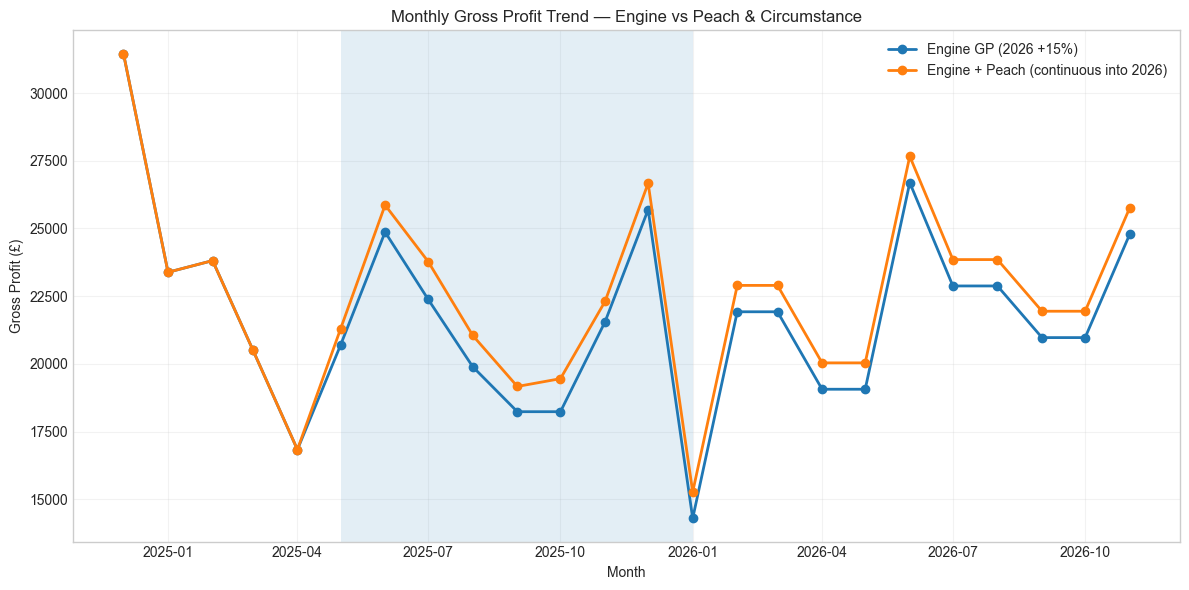

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# SETTINGS
# -----------------------------
PEACH_START = pd.Timestamp("2025-05-01")
GROWTH_2026 = 0.15   # +15% growth factor for 2026

# -----------------------------
# Prep plot dataframe
# -----------------------------
df_plot = df_13b.copy()

df_plot["date"] = pd.to_datetime(
    df_plot["year"].astype(int).astype(str) + "-" +
    df_plot["month"].astype(int).astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

df_plot = df_plot.dropna(subset=["date"]).sort_values("date")

# numeric safety
for col in ["gp_engine", "gp_peach"]:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce").fillna(0)

# -----------------------------
# Growth factor (2026 only)
# -----------------------------
df_plot["growth_factor"] = 1.0
df_plot.loc[df_plot["year"] == 2026, "growth_factor"] = 1.0 + GROWTH_2026

# -----------------------------
# Engine GP (grown)
# -----------------------------
df_plot["gp_engine_plot"] = df_plot["gp_engine"] * df_plot["growth_factor"]

# -----------------------------
# Peach GP carried into 2026
# -----------------------------
df_plot["peach_gp_cf"] = df_plot["gp_peach"].replace(0, pd.NA).ffill()

# only allow Peach from May 2025 onward
df_plot.loc[df_plot["date"] < PEACH_START, "peach_gp_cf"] = pd.NA

# -----------------------------
# Engine + Peach
# -----------------------------
df_plot["gp_plus_peach_plot"] = df_plot["gp_engine_plot"] + df_plot["peach_gp_cf"].fillna(0)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))

# Engine line (blue)
plt.plot(
    df_plot["date"],
    df_plot["gp_engine_plot"],
    marker="o",
    linewidth=2,
    label="Engine GP (2026 +15%)"
)

# Engine + Peach line (orange)
plt.plot(
    df_plot["date"],
    df_plot["gp_plus_peach_plot"],
    marker="o",
    linewidth=2,
    label="Engine + Peach (continuous into 2026)"
)

# Shade initiative window
plt.axvspan(pd.Timestamp("2025-05-01"), pd.Timestamp("2026-01-01"), alpha=0.12)

plt.title("Monthly Gross Profit Trend — Engine vs Peach & Circumstance")
plt.xlabel("Month")
plt.ylabel("Gross Profit (£)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("exports/13C_monthly_gp_trend.png", dpi=300, bbox_inches="tight")
plt.show()



#### 13D) P&C initiative contribution

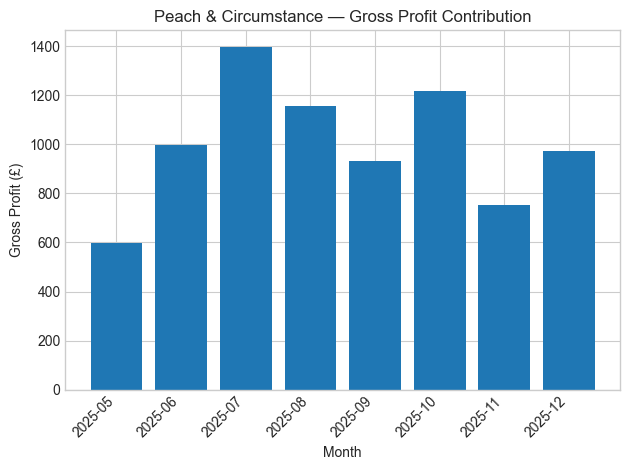

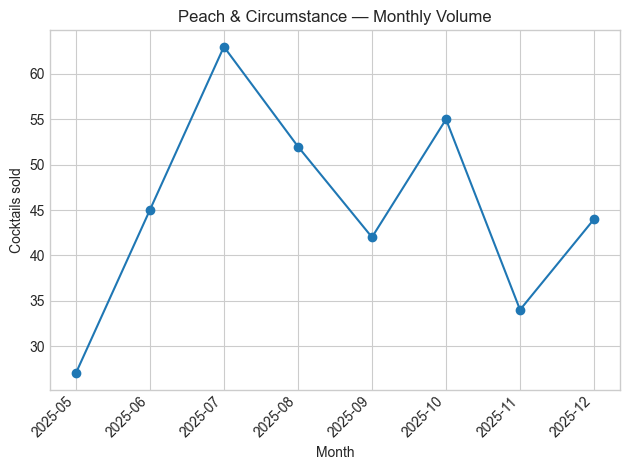

,year,month,qty,gp,ym
0,2025,5,27,598.05,2025-05
1,2025,6,45,996.75,2025-06
2,2025,7,63,1395.45,2025-07
3,2025,8,52,1155.60,2025-08
4,2025,9,42,931.50,2025-09
5,2025,10,55,1219.25,2025-10
6,2025,11,34,753.10,2025-11
7,2025,12,44,973.60,2025-12


In [15]:
import pandas as pd, sqlite3
import matplotlib.pyplot as plt

with sqlite3.connect(DB_PATH) as con:
    peach_m = pd.read_sql("""
        SELECT year, month, SUM(qty) AS qty, SUM(gp) AS gp
        FROM fact_manual_peach_13a1
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

peach_m["ym"] = peach_m["year"].astype(str) + "-" + peach_m["month"].astype(str).str.zfill(2)

plt.figure()
plt.bar(peach_m["ym"], peach_m["gp"])
plt.xticks(rotation=45, ha="right")
plt.title("Peach & Circumstance — Gross Profit Contribution")
plt.xlabel("Month")
plt.ylabel("Gross Profit (£)")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(peach_m["ym"], peach_m["qty"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Peach & Circumstance — Monthly Volume")
plt.xlabel("Month")
plt.ylabel("Cocktails sold")
plt.tight_layout()
plt.show()

peach_m

## 13E) KI NO BI Bottle Usage Forecast
Estimate monthly KI NO BI bottle usage from the Peach launch and the TYYM recipe switch.

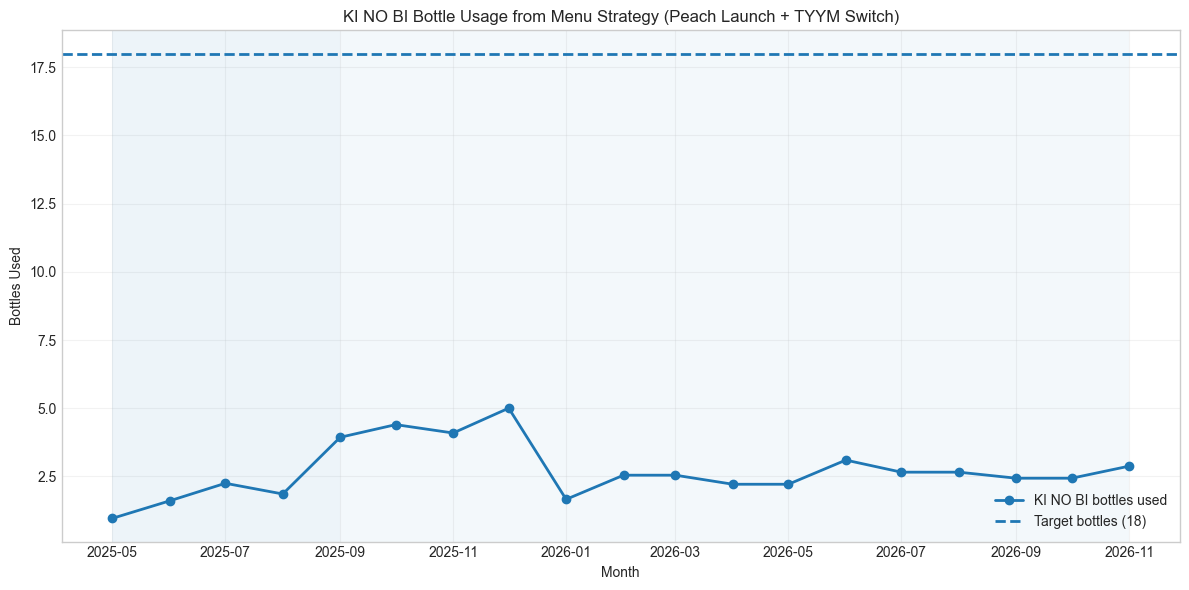

,year,month,peach_serves,tyym_serves,total_serves,ml_used,bottles_used
0,2025,5,27.0,0.0,27.0,675.0,0.964286
1,2025,6,45.0,0.0,45.0,1125.0,1.607143
2,2025,7,63.0,0.0,63.0,1575.0,2.250000
3,2025,8,52.0,0.0,52.0,1300.0,1.857143
4,2025,9,42.0,68.2,110.2,2755.0,3.935714
5,2025,10,55.0,68.2,123.2,3080.0,4.400000
6,2025,11,34.0,80.6,114.6,2865.0,4.092857
7,2025,12,44.0,96.1,140.1,3502.5,5.003571
8,2026,1,0.0,46.5,46.5,1162.5,1.660714
9,2026,2,0.0,71.3,71.3,1782.5,2.546429


In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

ML_PER_SERVE = 25
ML_PER_BOTTLE = 700
TARGET_BOTTLES = 18

with sqlite3.connect(DB_PATH) as con:
    # 1) Peach manual serves (May 2025 onward)
    peach = pd.read_sql("""
        SELECT
            year,
            month,
            SUM(qty) AS peach_serves
        FROM fact_manual_peach_13a1
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

    # 2) TYYM serves from engine, but only Sep 2025 onward count toward KI NO BI
    tyym = pd.read_sql("""
        SELECT
            r.year,
            r.month,
            SUM(r.reality_forecast_qty) AS tyym_serves
        FROM fact_reality_forecast_14f r
        JOIN dim_cocktail c
          ON r.cocktail_id = c.cocktail_id
        WHERE c.cocktail_name = 'TYYM'
          AND (
                r.year > 2025
                OR (r.year = 2025 AND r.month >= 9)
              )
        GROUP BY r.year, r.month
        ORDER BY r.year, r.month;
    """, con)

# -----------------------------
# Build monthly scaffold
# -----------------------------
scaffold = pd.DataFrame({
    "date": pd.date_range("2025-05-01", "2026-11-01", freq="MS")
})
scaffold["year"] = scaffold["date"].dt.year
scaffold["month"] = scaffold["date"].dt.month
scaffold = scaffold.drop(columns=["date"])

kino = (
    scaffold
    .merge(peach, on=["year", "month"], how="left")
    .merge(tyym, on=["year", "month"], how="left")
    .fillna(0)
)

# -----------------------------
# Convert serves to KI NO BI usage
# -----------------------------
kino["total_serves"] = kino["peach_serves"] + kino["tyym_serves"]
kino["ml_used"] = kino["total_serves"] * ML_PER_SERVE
kino["bottles_used"] = kino["ml_used"] / ML_PER_BOTTLE

kino["date"] = pd.to_datetime(
    kino["year"].astype(str) + "-" + kino["month"].astype(str).str.zfill(2) + "-01"
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    kino["date"],
    kino["bottles_used"],
    marker="o",
    linewidth=2,
    label="KI NO BI bottles used"
)

plt.axhline(
    TARGET_BOTTLES,
    linestyle="--",
    linewidth=2,
    label="Target bottles (18)"
)

plt.axvspan(pd.Timestamp("2025-05-01"), pd.Timestamp("2025-09-01"), alpha=0.08)
plt.axvspan(pd.Timestamp("2025-09-01"), kino["date"].max(), alpha=0.05)

plt.title("KI NO BI Bottle Usage from Menu Strategy (Peach Launch + TYYM Switch)")
plt.xlabel("Month")
plt.ylabel("Bottles Used")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("exports/13E_kino_bottle_usage_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

kino[[
    "year","month",
    "peach_serves","tyym_serves","total_serves",
    "ml_used","bottles_used"
]]

## 13G) 2026 Seasonal Gross Profit Curve
Show the smoothed 2026 gross profit forecast using 2025 seasonality as the reference pattern.

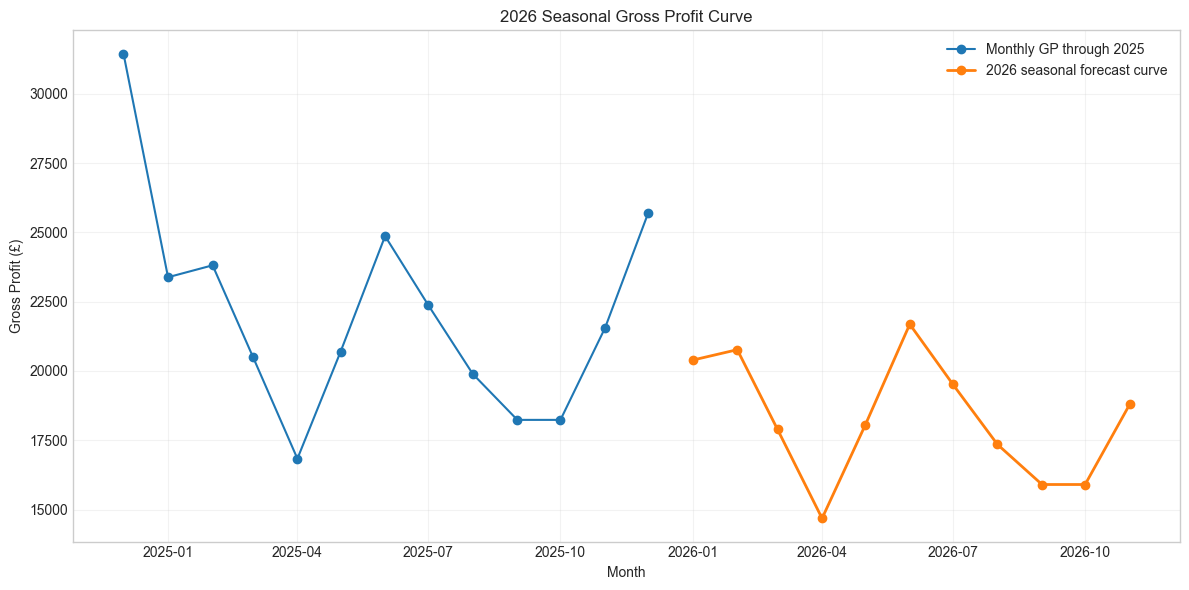

,year,month,gp,weight,gp_seasonal_curve
13,2026,1,12433.71,1.095658,20393.337814
14,2026,2,19065.00,1.115816,20768.541078
15,2026,3,19065.00,0.961361,17893.694985
16,2026,4,16578.26,0.788870,14683.135201
17,2026,5,16578.26,0.969537,18045.862400
18,2026,6,23209.56,1.165180,21687.345164
19,2026,7,19893.94,1.048662,19518.610648
20,2026,8,19893.94,0.932145,17349.893574
21,2026,9,18236.10,0.854465,15904.058935
22,2026,10,18236.10,0.854465,15904.058935


In [27]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

with sqlite3.connect(DB_PATH) as con:
    monthly = pd.read_sql("""
        SELECT year, month,
               SUM(forecast_gross_profit) AS gp
        FROM v_reality_financial_14g
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" +
    monthly["month"].astype(str).str.zfill(2) + "-01"
)

# --- build 2025 seasonal weights ---
m25 = monthly[monthly["year"] == 2025].copy()

avg25 = m25["gp"].mean()
m25["weight"] = m25["gp"] / avg25

season_map = dict(zip(m25["month"], m25["weight"]))

# --- apply weights to 2026 average GP ---
m26 = monthly[monthly["year"] == 2026].copy()

avg26 = m26["gp"].mean()
m26["weight"] = m26["month"].map(season_map).fillna(1.0)
m26["gp_seasonal_curve"] = avg26 * m26["weight"]

# --- plot ---
hist = monthly[monthly["year"] <= 2025].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    hist["date"],
    hist["gp"],
    marker="o",
    label="Monthly GP through 2025"
)

plt.plot(
    m26["date"],
    m26["gp_seasonal_curve"],
    marker="o",
    linewidth=2,
    label="2026 seasonal forecast curve"
)

plt.title("2026 Seasonal Gross Profit Curve")
plt.xlabel("Month")
plt.ylabel("Gross Profit (£)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("exports/13G_2026_seasonal_gp_curve.png", dpi=300, bbox_inches="tight")
plt.show()


m26[["year", "month", "gp", "weight", "gp_seasonal_curve"]]

## 13H) Monthly Gross Profit 
Rank the highest gross profit cocktails during the key commercial period.

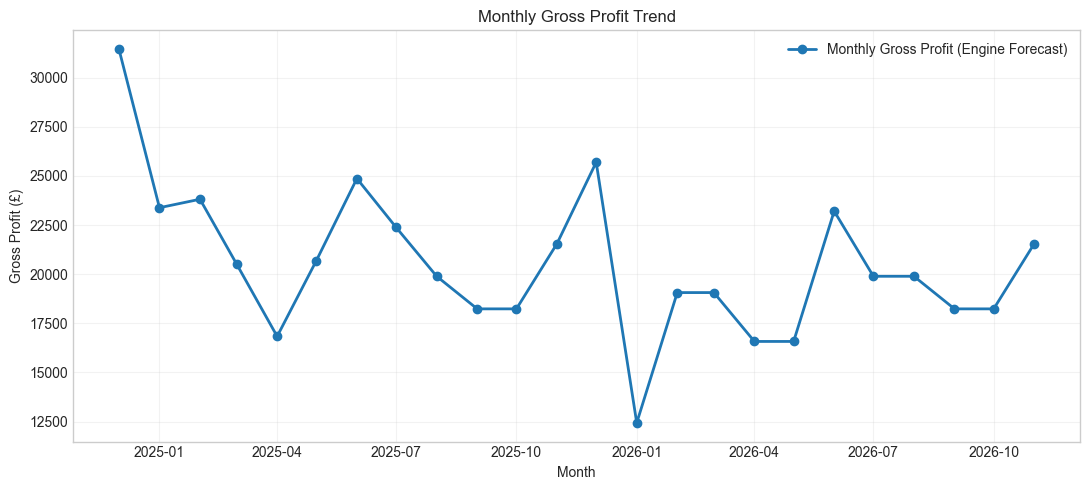

,year,month,gross_profit,date
6,2025,6,24867.40,2025-06-01
7,2025,7,22380.66,2025-07-01
8,2025,8,19893.94,2025-08-01
9,2025,9,18236.10,2025-09-01
10,2025,10,18236.10,2025-10-01
11,2025,11,21551.75,2025-11-01
12,2025,12,25696.31,2025-12-01
13,2026,1,12433.71,2026-01-01
14,2026,2,19065.00,2026-02-01
15,2026,3,19065.00,2026-03-01


In [28]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

with sqlite3.connect(DB_PATH) as con:
    df_13h = pd.read_sql("""
        SELECT
            year,
            month,
            SUM(forecast_gross_profit) AS gross_profit
        FROM v_reality_financial_14g
        GROUP BY year, month
        ORDER BY year, month;
    """, con)

# Build date column
df_13h["date"] = pd.to_datetime(
    df_13h["year"].astype(str) + "-" +
    df_13h["month"].astype(str).str.zfill(2) + "-01"
)

# Plot
plt.figure(figsize=(11,5))

plt.plot(
    df_13h["date"],
    df_13h["gross_profit"],
    marker="o",
    linewidth=2,
    label="Monthly Gross Profit (Engine Forecast)"
)

plt.title("Monthly Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Gross Profit (£)")
plt.grid(alpha=0.25)

plt.legend()
plt.tight_layout()
plt.savefig("exports/13H_monthly_gross_profit_trend.png", dpi=300, bbox_inches="tight")
plt.show()
df_13h.tail(18)

## 13I) Top Cocktails by Gross Profit
Rank the highest gross profit cocktails during the key commercial period.

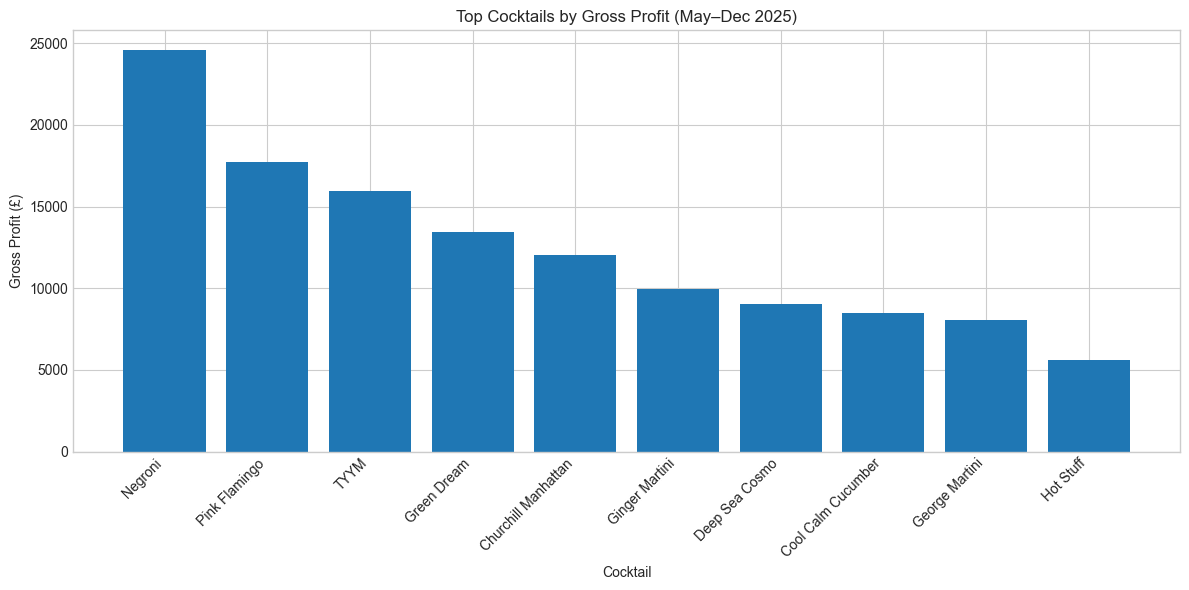

In [29]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

with sqlite3.connect(DB_PATH) as con:
    df_13i = pd.read_sql("""
        SELECT
            c.cocktail_name,
            ROUND(SUM(v.forecast_gross_profit), 2) AS gp
        FROM v_reality_financial_14g v
        JOIN dim_cocktail c
            ON v.cocktail_id = c.cocktail_id
        WHERE v.year = 2025
          AND v.month BETWEEN 5 AND 12
        GROUP BY c.cocktail_name
        ORDER BY gp DESC
        LIMIT 10;
    """, con)

df_13i

plt.figure(figsize=(12, 6))
plt.bar(df_13i["cocktail_name"], df_13i["gp"])
plt.title("Top Cocktails by Gross Profit (May–Dec 2025)")
plt.xlabel("Cocktail")
plt.ylabel("Gross Profit (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("exports/13I_top_cocktails_by_gp.png", dpi=300, bbox_inches="tight")
plt.show()

## 13J) Event Impact on Gross Profit
Compare baseline gross profit against event-adjusted forecast gross profit to isolate the impact of seasonal drivers.

✅ Exported 13J


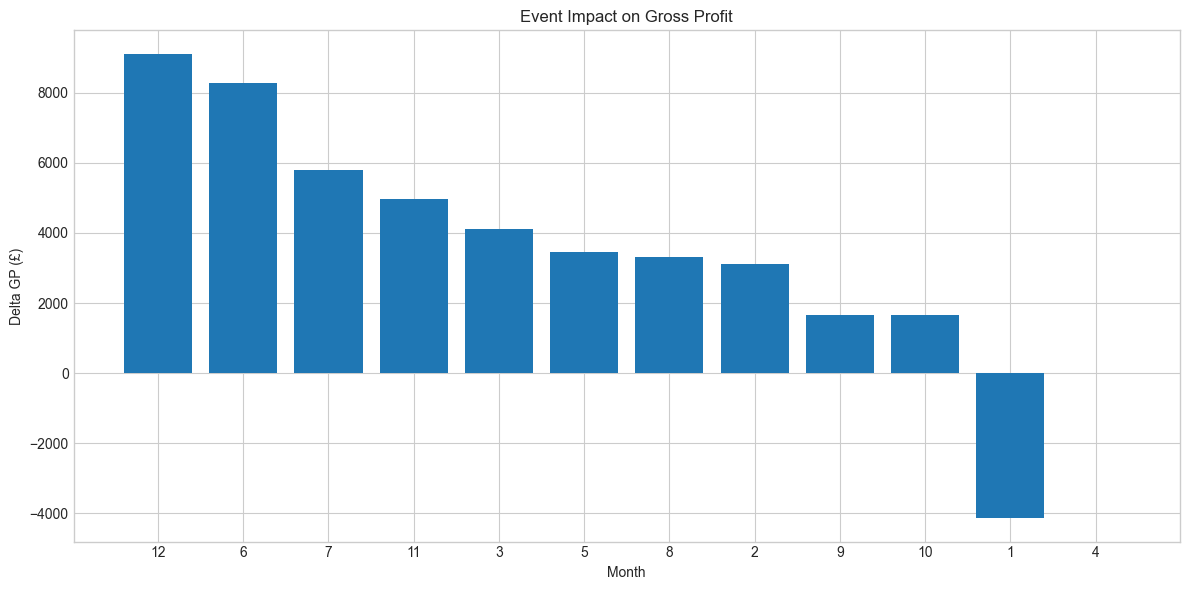

In [30]:
# 13J) Event Impact (Baseline GP vs Event-adjusted GP)

import pandas as pd
import sqlite3

with sqlite3.connect(DB_PATH) as con:
    df_13j = pd.read_sql("""
        SELECT
            r.year,
            r.month,

            ROUND(SUM(r.baseline_ma3 * p.sell_price - r.baseline_ma3 * c.cost_per_cocktail), 2) AS baseline_gp,

            ROUND(SUM(r.reality_forecast_qty * p.sell_price - r.reality_forecast_qty * c.cost_per_cocktail), 2) AS event_gp,

            ROUND(
                SUM(r.reality_forecast_qty * p.sell_price - r.reality_forecast_qty * c.cost_per_cocktail)
                -
                SUM(r.baseline_ma3 * p.sell_price - r.baseline_ma3 * c.cost_per_cocktail),
            2) AS delta_gp

        FROM v_reality_forecast_14e r
        LEFT JOIN fact_cocktail_price p
            ON r.cocktail_id = p.cocktail_id
        LEFT JOIN v_cost_per_cocktail c
            ON r.cocktail_id = c.cocktail_id
        GROUP BY r.year, r.month
        ORDER BY delta_gp DESC;
    """, con)

df_13j

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(df_13j["month"].astype(str), df_13j["delta_gp"])
plt.title("Event Impact on Gross Profit")
plt.xlabel("Month")
plt.ylabel("Delta GP (£)")
plt.tight_layout()
plt.savefig("exports/13J_event_impact_gp.png", dpi=300, bbox_inches="tight")
print("✅ Exported 13J")
plt.show()


#### 13K) KI NO BI Bottle Tracker

✅ Manual Peach qtys persisted to: fact_manual_monthly_qty_exec
✅ Built view: v_monthly_qty_exec_tracker (source = fact_reality_forecast_14f, override = manual first)


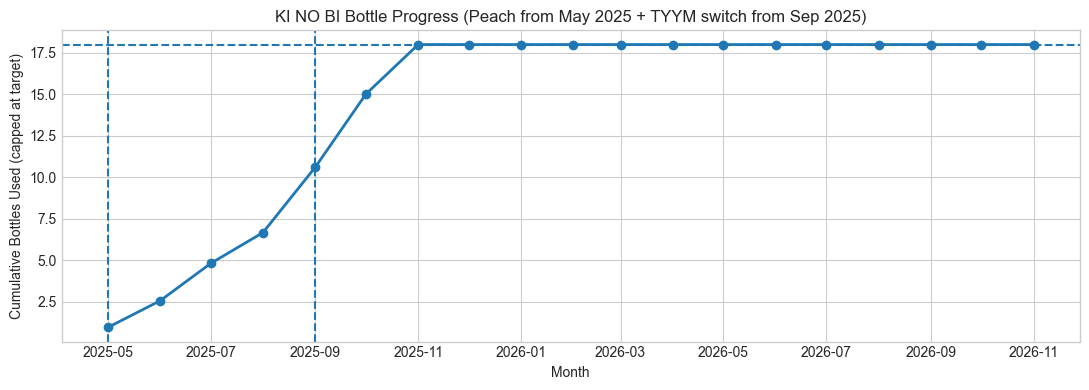

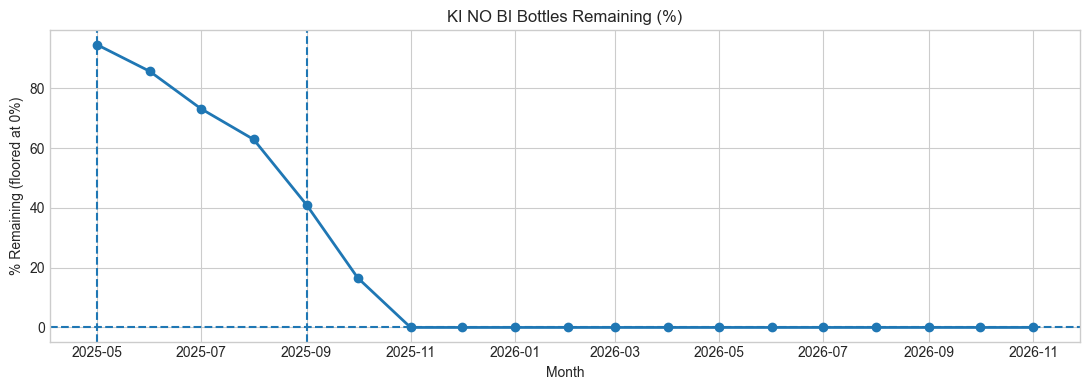

cocktail_name,date,qty_peach,qty_tyym,qty_peach_kinobi,qty_tyym_kinobi,qty_kinobi,bottles_used,cum_bottles_used,cum_bottles_used_capped,bottles_remaining_raw,bottles_remaining_pct_raw,bottles_remaining_pct
0,2025-05-01,27.0,80.0,27.0,0.0,27.0,0.964286,0.964286,0.964286,17.035714,0.946429,0.946429
1,2025-06-01,45.0,93.0,45.0,0.0,45.0,1.607143,2.571429,2.571429,15.428571,0.857143,0.857143
2,2025-07-01,63.0,83.7,63.0,0.0,63.0,2.250000,4.821429,4.821429,13.178571,0.732143,0.732143
3,2025-08-01,52.0,74.4,52.0,0.0,52.0,1.857143,6.678571,6.678571,11.321429,0.628968,0.628968
4,2025-09-01,42.0,68.2,42.0,68.2,110.2,3.935714,10.614286,10.614286,7.385714,0.410317,0.410317
5,2025-10-01,55.0,68.2,55.0,68.2,123.2,4.400000,15.014286,15.014286,2.985714,0.165873,0.165873
6,2025-11-01,34.0,80.6,34.0,80.6,114.6,4.092857,19.107143,18.000000,-1.107143,-0.061508,0.000000
7,2025-12-01,44.0,96.1,44.0,96.1,140.1,5.003571,24.110714,18.000000,-6.110714,-0.339484,0.000000
8,2026-01-01,0.0,46.5,0.0,46.5,46.5,1.660714,25.771429,18.000000,-7.771429,-0.431746,0.000000
9,2026-02-01,0.0,71.3,0.0,71.3,71.3,2.546429,28.317857,18.000000,-10.317857,-0.573214,0.000000


In [31]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


ML_PER_BOTTLE   = 700
ML_PER_COCKTAIL = 25
TARGET_BOTTLES  = 18

PEACH_NAME = "Peach & Circumstance"   
TYYM_NAME  = "TYYM"

PEACH_START_Y, PEACH_START_M = 2025, 5   
SWITCH_Y, SWITCH_M           = 2025, 9    


MANUAL_PEACH_QTYS = {
    (2025, 5): 27,
    (2025, 6): 45,
    (2025, 7): 63,
    (2025, 8): 52,
    (2025, 9): 42,
    (2025,10): 55,
    (2025,11): 34,
    (2025,12): 44,
}

def _exists(con, name: str) -> bool:
    return pd.read_sql(
        "SELECT 1 AS ok FROM sqlite_master WHERE name=? AND type IN ('table','view') LIMIT 1;",
        con, params=(name,)
    ).shape[0] > 0

def pick_best_source(con):
    """
    Returns (source_name, qty_col, needs_dim_join)
    qty_col is the column that holds monthly quantity
    needs_dim_join True only for fact_monthly_sales (id-based)
    """
    candidates = [
        ("fact_reality_forecast_14f", "reality_forecast_qty", False),
        ("v_reality_forecast_14f",    "reality_forecast_qty", False),
        ("v_reality_forecast_14e",    "reality_forecast_qty", False),
        ("fact_monthly_sales",        "quantity_sold",        True),
    ]
    for name, qty_col, needs_join in candidates:
        if _exists(con, name):
            return name, qty_col, needs_join
    raise RuntimeError(
        "No usable monthly quantity source found. Expected one of: "
        "fact_reality_forecast_14f / v_reality_forecast_14f / v_reality_forecast_14e / fact_monthly_sales"
    )


# 1) Persist manual Peach qtys into SQLite

with sqlite3.connect(DB_PATH) as con:
    cur = con.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS fact_manual_monthly_qty_exec (
            year          INTEGER NOT NULL,
            month         INTEGER NOT NULL,
            cocktail_name TEXT    NOT NULL,
            qty           REAL    NOT NULL,
            notes         TEXT,
            PRIMARY KEY (year, month, cocktail_name)
        );
    """)

    rows = [(y, m, PEACH_NAME, float(q), "manual Peach qty (exec portfolio)")
            for (y, m), q in MANUAL_PEACH_QTYS.items()]

    cur.executemany("""
        INSERT INTO fact_manual_monthly_qty_exec (year, month, cocktail_name, qty, notes)
        VALUES (?, ?, ?, ?, ?)
        ON CONFLICT(year, month, cocktail_name)
        DO UPDATE SET qty=excluded.qty, notes=excluded.notes;
    """, rows)

    con.commit()

print("✅ Manual Peach qtys persisted to: fact_manual_monthly_qty_exec")

with sqlite3.connect(DB_PATH) as con:
    src_name, src_qtycol, needs_dim_join = pick_best_source(con)
    cur = con.cursor()

    cur.execute("DROP VIEW IF EXISTS v_monthly_qty_exec_tracker;")

    if needs_dim_join:
        # fact_monthly_sales is cocktail_id-based
        cur.execute(f"""
            CREATE VIEW v_monthly_qty_exec_tracker AS
            WITH base AS (
                SELECT
                    s.year,
                    s.month,
                    d.cocktail_name,
                    SUM(s.{src_qtycol}) AS qty
                FROM {src_name} s
                JOIN dim_cocktail d ON d.cocktail_id = s.cocktail_id
                GROUP BY s.year, s.month, d.cocktail_name
            ),
            manual AS (
                SELECT year, month, cocktail_name, qty
                FROM fact_manual_monthly_qty_exec
            ),
            keys AS (
                SELECT year, month, cocktail_name FROM base
                UNION
                SELECT year, month, cocktail_name FROM manual
            )
            SELECT
                k.year,
                k.month,
                k.cocktail_name,
                COALESCE(m.qty, b.qty, 0.0) AS qty
            FROM keys k
            LEFT JOIN base   b ON b.year=k.year AND b.month=k.month AND b.cocktail_name=k.cocktail_name
            LEFT JOIN manual m ON m.year=k.year AND m.month=k.month AND m.cocktail_name=k.cocktail_name;
        """)
    else:
        # reality/forecast views/tables already have cocktail_name
        cur.execute(f"""
            CREATE VIEW v_monthly_qty_exec_tracker AS
            WITH base AS (
                SELECT
                    year,
                    month,
                    cocktail_name,
                    SUM({src_qtycol}) AS qty
                FROM {src_name}
                GROUP BY year, month, cocktail_name
            ),
            manual AS (
                SELECT year, month, cocktail_name, qty
                FROM fact_manual_monthly_qty_exec
            ),
            keys AS (
                SELECT year, month, cocktail_name FROM base
                UNION
                SELECT year, month, cocktail_name FROM manual
            )
            SELECT
                k.year,
                k.month,
                k.cocktail_name,
                COALESCE(m.qty, b.qty, 0.0) AS qty
            FROM keys k
            LEFT JOIN base   b ON b.year=k.year AND b.month=k.month AND b.cocktail_name=k.cocktail_name
            LEFT JOIN manual m ON m.year=k.year AND m.month=k.month AND m.cocktail_name=k.cocktail_name;
        """)

    con.commit()

print(f"✅ Built view: v_monthly_qty_exec_tracker (source = {src_name}, override = manual first)")


# 3) Load unified monthly qtys for Peach + TYYM

with sqlite3.connect(DB_PATH) as con:
    df = pd.read_sql("""
        SELECT year, month, cocktail_name, qty
        FROM v_monthly_qty_exec_tracker
        WHERE cocktail_name IN (?, ?)
        ORDER BY year, month, cocktail_name;
    """, con, params=(PEACH_NAME, TYYM_NAME))

# Exec horizon spine (May 2025 -> Nov 2026)
start = pd.Timestamp(year=2025, month=5, day=1)
end   = pd.Timestamp(year=2026, month=11, day=1)
spine = pd.date_range(start=start, end=end, freq="MS")

df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-01")

p = (df.pivot_table(index="date", columns="cocktail_name", values="qty", aggfunc="sum")
       .reindex(spine)
       .fillna(0.0)
       .reset_index()
       .rename(columns={"index": "date"}))

p["year"]  = p["date"].dt.year
p["month"] = p["date"].dt.month

p["qty_peach"] = p.get(PEACH_NAME, 0.0)
p["qty_tyym"]  = p.get(TYYM_NAME,  0.0)


# 4) Apply KI NO BI switch rules

peach_start = pd.Timestamp(year=PEACH_START_Y, month=PEACH_START_M, day=1)
switch_date = pd.Timestamp(year=SWITCH_Y,      month=SWITCH_M,      day=1)

# Peach counts from May 2025 (manual already supplied there; view handles override)
p["qty_peach_kinobi"] = p["qty_peach"].where(p["date"] >= peach_start, 0.0)

# TYYM counts only from Sep 2025 onward (ingredient switch only)
p["qty_tyym_kinobi"]  = p["qty_tyym"].where(p["date"] >= switch_date, 0.0)

p["qty_kinobi"] = p["qty_peach_kinobi"] + p["qty_tyym_kinobi"]

# Convert to bottles
p["ml_used"]         = p["qty_kinobi"] * ML_PER_COCKTAIL
p["bottles_used"]    = p["ml_used"] / ML_PER_BOTTLE
p["cum_bottles_used"] = p["bottles_used"].cumsum()

# Portfolio display logic
p["cum_bottles_used_capped"] = p["cum_bottles_used"].clip(upper=TARGET_BOTTLES)
p["bottles_remaining_raw"]   = TARGET_BOTTLES - p["cum_bottles_used"]
p["bottles_remaining_pct_raw"] = p["bottles_remaining_raw"] / TARGET_BOTTLES
p["bottles_remaining_pct"]     = p["bottles_remaining_pct_raw"].clip(lower=0, upper=1)

# -----------------------------------------
# 5) Plots
# -----------------------------------------
plt.figure(figsize=(11, 4))
plt.plot(p["date"], p["cum_bottles_used_capped"], marker="o", linewidth=2)
plt.axhline(TARGET_BOTTLES, linestyle="--")
plt.axvline(peach_start, linestyle="--")
plt.axvline(switch_date, linestyle="--")
plt.title("KI NO BI Bottle Progress (Peach from May 2025 + TYYM switch from Sep 2025)")
plt.xlabel("Month")
plt.ylabel("Cumulative Bottles Used (capped at target)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(p["date"], p["bottles_remaining_pct"] * 100, marker="o", linewidth=2)
plt.axhline(0, linestyle="--")
plt.axvline(peach_start, linestyle="--")
plt.axvline(switch_date, linestyle="--")
plt.title("KI NO BI Bottles Remaining (%)")
plt.xlabel("Month")
plt.ylabel("% Remaining (floored at 0%)")
plt.tight_layout()
plt.savefig("exports/13H_monthly_gross_profit_trend.png", dpi=300)
plt.show()

# -----------------------------------------
# 6) Output table (sanity check)
# -----------------------------------------
cols_out = [
    "date",
    "qty_peach","qty_tyym",
    "qty_peach_kinobi","qty_tyym_kinobi","qty_kinobi",
    "bottles_used","cum_bottles_used","cum_bottles_used_capped",
    "bottles_remaining_raw","bottles_remaining_pct_raw","bottles_remaining_pct"
]
p[cols_out].tail(20)

## 13L) Expots CSV's and PNG's 

✅ Manual Peach qtys persisted
✅ Built view: v_monthly_qty_exec_tracker (source = fact_reality_forecast_14f)
✅ CSV exported: exports/13K_kino_bottle_tracker.csv


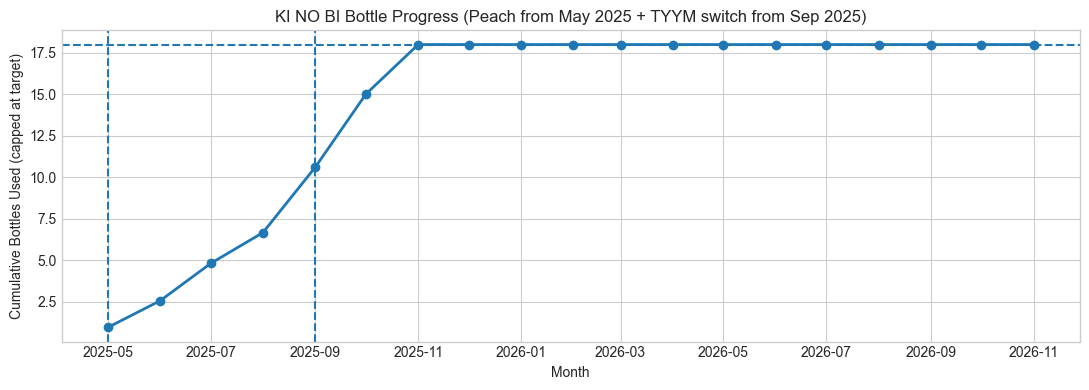

✅ PNG exported: exports/13K_kino_bottle_progress.png


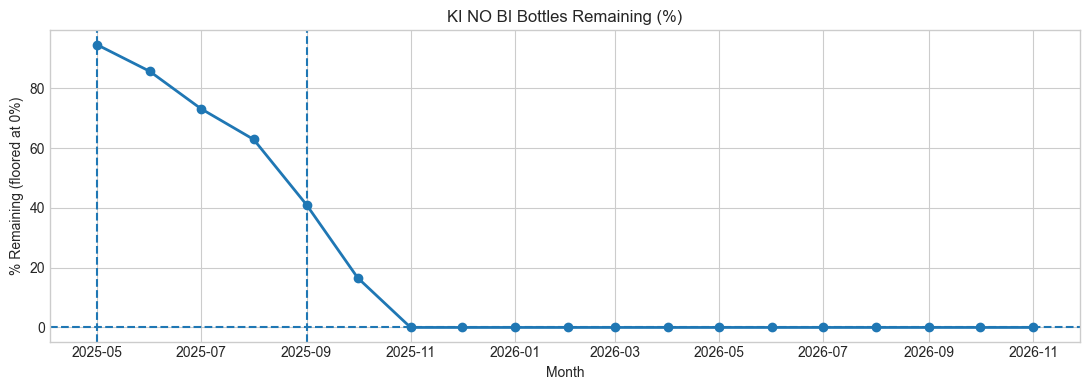

✅ PNG exported: exports/13K_kino_bottles_remaining_pct.png


cocktail_name,date,qty_peach,qty_tyym,qty_peach_kinobi,qty_tyym_kinobi,qty_kinobi,ml_used,bottles_used,cum_bottles_used,cum_bottles_used_capped,bottles_remaining_raw,bottles_remaining_pct_raw,bottles_remaining_pct
0,2025-05-01,27.0,80.0,27.0,0.0,27.0,675.0,0.964286,0.964286,0.964286,17.035714,0.946429,0.946429
1,2025-06-01,45.0,93.0,45.0,0.0,45.0,1125.0,1.607143,2.571429,2.571429,15.428571,0.857143,0.857143
2,2025-07-01,63.0,83.7,63.0,0.0,63.0,1575.0,2.250000,4.821429,4.821429,13.178571,0.732143,0.732143
3,2025-08-01,52.0,74.4,52.0,0.0,52.0,1300.0,1.857143,6.678571,6.678571,11.321429,0.628968,0.628968
4,2025-09-01,42.0,68.2,42.0,68.2,110.2,2755.0,3.935714,10.614286,10.614286,7.385714,0.410317,0.410317
5,2025-10-01,55.0,68.2,55.0,68.2,123.2,3080.0,4.400000,15.014286,15.014286,2.985714,0.165873,0.165873
6,2025-11-01,34.0,80.6,34.0,80.6,114.6,2865.0,4.092857,19.107143,18.000000,-1.107143,-0.061508,0.000000
7,2025-12-01,44.0,96.1,44.0,96.1,140.1,3502.5,5.003571,24.110714,18.000000,-6.110714,-0.339484,0.000000
8,2026-01-01,0.0,46.5,0.0,46.5,46.5,1162.5,1.660714,25.771429,18.000000,-7.771429,-0.431746,0.000000
9,2026-02-01,0.0,71.3,0.0,71.3,71.3,1782.5,2.546429,28.317857,18.000000,-10.317857,-0.573214,0.000000


In [32]:
# 13K) Export KI NO BI tracker outputs (CSV + PNG)

import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
ML_PER_BOTTLE   = 700
ML_PER_COCKTAIL = 25
TARGET_BOTTLES  = 18

PEACH_NAME = "Peach & Circumstance"
TYYM_NAME  = "TYYM"

PEACH_START_Y, PEACH_START_M = 2025, 5
SWITCH_Y, SWITCH_M           = 2025, 9

MANUAL_PEACH_QTYS = {
    (2025, 5): 27,
    (2025, 6): 45,
    (2025, 7): 63,
    (2025, 8): 52,
    (2025, 9): 42,
    (2025,10): 55,
    (2025,11): 34,
    (2025,12): 44,
}

os.makedirs("exports", exist_ok=True)

def _exists(con, name: str) -> bool:
    return pd.read_sql(
        "SELECT 1 AS ok FROM sqlite_master WHERE name=? AND type IN ('table','view') LIMIT 1;",
        con, params=(name,)
    ).shape[0] > 0

def pick_best_source(con):
    candidates = [
        ("fact_reality_forecast_14f", "reality_forecast_qty", False),
        ("v_reality_forecast_14f",    "reality_forecast_qty", False),
        ("v_reality_forecast_14e",    "reality_forecast_qty", False),
        ("fact_monthly_sales",        "quantity_sold",        True),
    ]
    for name, qty_col, needs_join in candidates:
        if _exists(con, name):
            return name, qty_col, needs_join
    raise RuntimeError(
        "No usable monthly quantity source found. Expected one of: "
        "fact_reality_forecast_14f / v_reality_forecast_14f / v_reality_forecast_14e / fact_monthly_sales"
    )

# -----------------------------
# 1) Persist manual Peach qtys
# -----------------------------
with sqlite3.connect(DB_PATH) as con:
    cur = con.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS fact_manual_monthly_qty_exec (
            year          INTEGER NOT NULL,
            month         INTEGER NOT NULL,
            cocktail_name TEXT    NOT NULL,
            qty           REAL    NOT NULL,
            notes         TEXT,
            PRIMARY KEY (year, month, cocktail_name)
        );
    """)

    rows = [
        (y, m, PEACH_NAME, float(q), "manual Peach qty (exec portfolio)")
        for (y, m), q in MANUAL_PEACH_QTYS.items()
    ]

    cur.executemany("""
        INSERT INTO fact_manual_monthly_qty_exec (year, month, cocktail_name, qty, notes)
        VALUES (?, ?, ?, ?, ?)
        ON CONFLICT(year, month, cocktail_name)
        DO UPDATE SET qty=excluded.qty, notes=excluded.notes;
    """, rows)

    con.commit()

print("✅ Manual Peach qtys persisted")

# -----------------------------
# 2) Build unified exec tracker view
# -----------------------------
with sqlite3.connect(DB_PATH) as con:
    src_name, src_qtycol, needs_dim_join = pick_best_source(con)
    cur = con.cursor()

    cur.execute("DROP VIEW IF EXISTS v_monthly_qty_exec_tracker;")

    if needs_dim_join:
        cur.execute(f"""
            CREATE VIEW v_monthly_qty_exec_tracker AS
            WITH base AS (
                SELECT
                    s.year,
                    s.month,
                    d.cocktail_name,
                    SUM(s.{src_qtycol}) AS qty
                FROM {src_name} s
                JOIN dim_cocktail d ON d.cocktail_id = s.cocktail_id
                GROUP BY s.year, s.month, d.cocktail_name
            ),
            manual AS (
                SELECT year, month, cocktail_name, qty
                FROM fact_manual_monthly_qty_exec
            ),
            keys AS (
                SELECT year, month, cocktail_name FROM base
                UNION
                SELECT year, month, cocktail_name FROM manual
            )
            SELECT
                k.year,
                k.month,
                k.cocktail_name,
                COALESCE(m.qty, b.qty, 0.0) AS qty
            FROM keys k
            LEFT JOIN base   b ON b.year=k.year AND b.month=k.month AND b.cocktail_name=k.cocktail_name
            LEFT JOIN manual m ON m.year=k.year AND m.month=k.month AND m.cocktail_name=k.cocktail_name;
        """)
    else:
        cur.execute(f"""
            CREATE VIEW v_monthly_qty_exec_tracker AS
            WITH base AS (
                SELECT
                    year,
                    month,
                    cocktail_name,
                    SUM({src_qtycol}) AS qty
                FROM {src_name}
                GROUP BY year, month, cocktail_name
            ),
            manual AS (
                SELECT year, month, cocktail_name, qty
                FROM fact_manual_monthly_qty_exec
            ),
            keys AS (
                SELECT year, month, cocktail_name FROM base
                UNION
                SELECT year, month, cocktail_name FROM manual
            )
            SELECT
                k.year,
                k.month,
                k.cocktail_name,
                COALESCE(m.qty, b.qty, 0.0) AS qty
            FROM keys k
            LEFT JOIN base   b ON b.year=k.year AND b.month=k.month AND b.cocktail_name=k.cocktail_name
            LEFT JOIN manual m ON m.year=k.year AND m.month=k.month AND m.cocktail_name=k.cocktail_name;
        """)

    con.commit()

print(f"✅ Built view: v_monthly_qty_exec_tracker (source = {src_name})")

# -----------------------------
# 3) Load Peach + TYYM monthly qtys
# -----------------------------
with sqlite3.connect(DB_PATH) as con:
    df = pd.read_sql("""
        SELECT year, month, cocktail_name, qty
        FROM v_monthly_qty_exec_tracker
        WHERE cocktail_name IN (?, ?)
        ORDER BY year, month, cocktail_name;
    """, con, params=(PEACH_NAME, TYYM_NAME))

start = pd.Timestamp(year=2025, month=5, day=1)
end   = pd.Timestamp(year=2026, month=11, day=1)
spine = pd.date_range(start=start, end=end, freq="MS")

df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-01"
)

p = (
    df.pivot_table(index="date", columns="cocktail_name", values="qty", aggfunc="sum")
      .reindex(spine)
      .fillna(0.0)
      .reset_index()
      .rename(columns={"index": "date"})
)

p["year"]  = p["date"].dt.year
p["month"] = p["date"].dt.month

p["qty_peach"] = p.get(PEACH_NAME, 0.0)
p["qty_tyym"]  = p.get(TYYM_NAME, 0.0)

# -----------------------------
# 4) Apply KI NO BI switch rules
# -----------------------------
peach_start = pd.Timestamp(year=PEACH_START_Y, month=PEACH_START_M, day=1)
switch_date = pd.Timestamp(year=SWITCH_Y,      month=SWITCH_M,      day=1)

p["qty_peach_kinobi"] = p["qty_peach"].where(p["date"] >= peach_start, 0.0)
p["qty_tyym_kinobi"]  = p["qty_tyym"].where(p["date"] >= switch_date, 0.0)

p["qty_kinobi"] = p["qty_peach_kinobi"] + p["qty_tyym_kinobi"]

p["ml_used"]          = p["qty_kinobi"] * ML_PER_COCKTAIL
p["bottles_used"]     = p["ml_used"] / ML_PER_BOTTLE
p["cum_bottles_used"] = p["bottles_used"].cumsum()

p["cum_bottles_used_capped"] = p["cum_bottles_used"].clip(upper=TARGET_BOTTLES)
p["bottles_remaining_raw"]   = TARGET_BOTTLES - p["cum_bottles_used"]
p["bottles_remaining_pct_raw"] = p["bottles_remaining_raw"] / TARGET_BOTTLES
p["bottles_remaining_pct"]     = p["bottles_remaining_pct_raw"].clip(lower=0, upper=1)

# -----------------------------
# 5) EXPORT CSV
# -----------------------------
csv_cols = [
    "date",
    "qty_peach","qty_tyym",
    "qty_peach_kinobi","qty_tyym_kinobi","qty_kinobi",
    "ml_used","bottles_used","cum_bottles_used","cum_bottles_used_capped",
    "bottles_remaining_raw","bottles_remaining_pct_raw","bottles_remaining_pct"
]

p[csv_cols].to_csv("exports/13K_kino_bottle_tracker.csv", index=False)
print("✅ CSV exported: exports/13K_kino_bottle_tracker.csv")

# -----------------------------
# 6) EXPORT PNG 1 — cumulative progress
# -----------------------------
plt.figure(figsize=(11, 4))
plt.plot(p["date"], p["cum_bottles_used_capped"], marker="o", linewidth=2)
plt.axhline(TARGET_BOTTLES, linestyle="--")
plt.axvline(peach_start, linestyle="--")
plt.axvline(switch_date, linestyle="--")
plt.title("KI NO BI Bottle Progress (Peach from May 2025 + TYYM switch from Sep 2025)")
plt.xlabel("Month")
plt.ylabel("Cumulative Bottles Used (capped at target)")
plt.tight_layout()
plt.savefig("exports/13K_kino_bottle_progress.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✅ PNG exported: exports/13K_kino_bottle_progress.png")

# -----------------------------
# 7) EXPORT PNG 2 — remaining %
# -----------------------------
plt.figure(figsize=(11, 4))
plt.plot(p["date"], p["bottles_remaining_pct"] * 100, marker="o", linewidth=2)
plt.axhline(0, linestyle="--")
plt.axvline(peach_start, linestyle="--")
plt.axvline(switch_date, linestyle="--")
plt.title("KI NO BI Bottles Remaining (%)")
plt.xlabel("Month")
plt.ylabel("% Remaining (floored at 0%)")
plt.tight_layout()
plt.savefig("exports/13K_kino_bottles_remaining_pct.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✅ PNG exported: exports/13K_kino_bottles_remaining_pct.png")

# -----------------------------
# 8) Final sanity table
# -----------------------------
p[csv_cols].tail(20)

## Save Charts as PNGs 